In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Please refer to BED file format
# https://en.wikipedia.org/wiki/BED_(file_format)

def load_data(file_name):
    columns = ['chrom', 'chromStart', 'chromEnd', 'name']
    df = pd.read_csv(file_name, sep="\t", header=None, names=columns)
    return df

In [3]:
def select_data(df, start, end):
    df.sort_values(by='chromStart', ascending=True, inplace=True)
    return df[(df['chromStart'] >= start) & (df['chromStart'] <= end)]

In [4]:
# Create a new dataframe for visualization
# 1. Create entry by chrom, new rows from chromStart to chromEnd, name, value = 1

# for index, row in h3k4me_df.iterrows():
#     print(row['chrom'], row['chromStart'], row['chromEnd'], row['name'])

# h3k4me_explode_df = pd.DataFrame(columns=['idx', 'chrom', 'val', 'name'])

def padding_data(df):
    index = []
    chrom = []
    val = []
    name = []
    prev = 0
    is_beginning = True

    for row in df.itertuples():
        start = row.chromStart
        stop = row.chromEnd

        if(is_beginning):
            # print(f"Processing: {start} - {stop}")
            index += [i for i in range(start, stop + 1)]
            chrom += [row.chrom for i in range(start, stop + 1)]
            val += [1 for i in range(start, stop + 1) ]
            name += [row.name for i in range(start, stop + 1)]
            prev = stop + 1
            is_beginning = False
        else:
            # print(f"Processing: {start} - {stop} - {prev}")
            # Padding the previous entry with 0
            index += [i for i in range(prev, start-1)]
            chrom += ["NA" for i in range(prev, start-1)]
            val += [0 for i in range(prev, start-1)]
            name += ["NA" for i in range(prev, start-1)]

            # Process the next entry
            index += [i for i in range(start, stop + 1)]
            chrom += [row.chrom for i in range(start, stop + 1)]
            val += [1 for i in range(start, stop + 1) ]
            name += [row.name for i in range(start, stop + 1)]
            prev = stop + 1
    
    return index, chrom, val, name

In [5]:
def df_from_dict(index, chrom, val, name):
    data_dict = {
        "index": index,
        "chrom": chrom,
        "val": val,
        "name": name
    }

    return pd.DataFrame.from_dict(data_dict)

In [6]:
def prepare_df(file_name, start, end):
    df = load_data(file_name)
    selected_df = select_data(df, start, end)
    index, chrom, val, name = padding_data(selected_df)
    vis_df = df_from_dict(index, chrom, val, name)

    return vis_df

In [113]:
start = 7016000
end = 7020000

h3k4me3_df = prepare_df("dataset/HepG2_Male.histone.H3K4me3.peak.bed", start, end)
h3k9ac_df = prepare_df("dataset/HepG2_Male.histone.H3K9ac.peak.bed", start, end)
h3k27ac_df = prepare_df("dataset/HepG2_Male.histone.H3K27ac.peak.bed", start, end)
h3k27me3_df = prepare_df("dataset/HepG2_Male.histone.H3K27me3.peak.bed", start, end)
h3k9me3_df = prepare_df("dataset/HepG2_Male.histone.H3K9me3.peak.bed", start, end)
nucleosome_df = prepare_df("dataset/HepG2_Male.nucleosome.peak.bed", start, end)

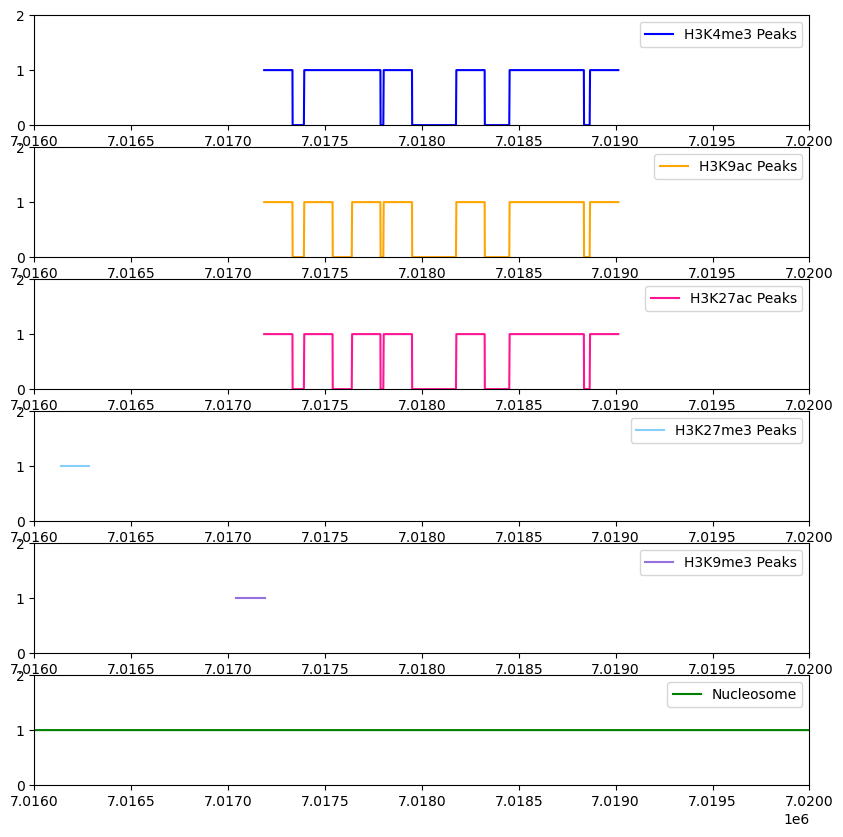

In [114]:
# Plot all the peaks
fig, axs = plt.subplots(6, 1, figsize=(10, 10))

plt.setp(axs, xlim = (start, end), ylim = (0.0, 2.0))

# Plot h3k4me
axs[0].plot(h3k4me3_df["index"], h3k4me3_df["val"], color="blue", label="H3K4me3 Peaks")
axs[0].legend(loc="upper right")

# Plot h3k9ac
axs[1].plot(h3k9ac_df["index"], h3k9ac_df["val"], color="orange", label="H3K9ac Peaks")
axs[1].legend(loc="upper right")

# Plot h3k27ac
axs[2].plot(h3k27ac_df["index"], h3k27ac_df["val"], color="deeppink", label="H3K27ac Peaks")
axs[2].legend(loc="upper right")

# Plot h3k27me3
axs[3].plot(h3k27me3_df["index"], h3k27me3_df["val"], color="lightskyblue", label="H3K27me3 Peaks")
axs[3].legend(loc="upper right")

# Plot h3k9me3
axs[4].plot(h3k9me3_df["index"], h3k9me3_df["val"], color="mediumpurple", label="H3K9me3 Peaks")
axs[4].legend(loc="upper right")

# Plot nucleosome
axs[5].plot(nucleosome_df["index"], nucleosome_df["val"], color="green", label="Nucleosome")
axs[5].legend(loc="upper right")

In [ ]:
nc_df = load_data("dataset/HepG2_Male.nucleosome.peak.bed")
nc_df = select_data(nc_df, start, end)
nc_df.head()